# Модель, прогнозирующая выдачу кредита

In [26]:
!pip install --upgrade kaleido


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import os
import matplotlib.pyplot as plt
import warnings
import optuna
from phik.report import plot_correlation_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from typing import Dict, List, Optional, Any, Callable
from alembic.ddl.base import DropColumn
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, average_precision_score, confusion_matrix, roc_curve, precision_recall_curve, auc
from dataclasses import dataclass, field
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
from abc import ABC, abstractmethod
from ydata_profiling import ProfileReport
from sklearn.linear_model import LogisticRegression
from scipy.stats import loguniform, uniform
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from lightgbm import LGBMClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.model_selection import HalvingGridSearchCV, StratifiedKFold

import time
import tracemalloc
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler


## EDA

In [28]:
df = pd.read_csv('../data/train.csv')

In [29]:
df

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
58640,58640,34,120000,MORTGAGE,5.0,EDUCATION,D,25000,15.95,0.21,Y,10,0
58641,58641,28,28800,RENT,0.0,MEDICAL,C,10000,12.73,0.35,N,8,1
58642,58642,23,44000,RENT,7.0,EDUCATION,D,6800,16.00,0.15,N,2,1
58643,58643,22,30000,RENT,2.0,EDUCATION,A,5000,8.90,0.17,N,3,0


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          58645 non-null  int64  
 1   person_age                  58645 non-null  int64  
 2   person_income               58645 non-null  int64  
 3   person_home_ownership       58645 non-null  object 
 4   person_emp_length           58645 non-null  float64
 5   loan_intent                 58645 non-null  object 
 6   loan_grade                  58645 non-null  object 
 7   loan_amnt                   58645 non-null  int64  
 8   loan_int_rate               58645 non-null  float64
 9   loan_percent_income         58645 non-null  float64
 10  cb_person_default_on_file   58645 non-null  object 
 11  cb_person_cred_hist_length  58645 non-null  int64  
 12  loan_status                 58645 non-null  int64  
dtypes: float64(3), int64(6), object

Датасет имеет 13 признаков, из которых 9 числовых и 4 категориальных. Всего в датасете 58645 строк, пропуски отсутствуют.\
**id** - порядковый номер строки\
**person_age** - возраст заёмщика\
**person_income** - доход заёмщика\
**person_home_ownership** - право на собственное жилье (аренда, ипотека, собственность без обременения, другое, в датасете это 'RENT', 'OWN', 'MORTGAGE', 'OTHER')\
**person_emp_length** - опыт работы\
**loan_intent** - цель займа (образование, медицина, личное, инвестиции, рефинансирование, ремонт, в датасете это 'EDUCATION', 'MEDICAL', 'PERSONAL', 'VENTURE', 'DEBTCONSOLIDATION', 'HOMEIMPROVEMENT')\
**loan_grade** - кредитный рейтинг заемщика (A-G)\
**loan_amnt** - размер займа\
**loan_int_rate** - процентная ставка по займу\
**loan_percent_income** - отношение размера займа к доходу\
**cb_person_default_on_file** - признак того, что у заёмщика случился дефолт\
**cb_person_cred_hist_length** - длина кредитной истории заёмщика\
**loan_status** - признак, выдать ли займ

In [31]:
df.describe()

,id,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status
count,58645.000000,58645.000000,5.864500e+04,58645.000000,58645.000000,58645.000000,58645.000000,58645.000000,58645.000000
mean,29322.000000,27.550857,6.404617e+04,4.701015,9217.556518,10.677874,0.159238,5.813556,0.142382
std,16929.497605,6.033216,3.793111e+04,3.959784,5563.807384,3.034697,0.091692,4.029196,0.349445
min,0.000000,20.000000,4.200000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,0.000000
25%,14661.000000,23.000000,4.200000e+04,2.000000,5000.000000,7.880000,0.090000,3.000000,0.000000
50%,29322.000000,26.000000,5.800000e+04,4.000000,8000.000000,10.750000,0.140000,4.000000,0.000000
75%,43983.000000,30.000000,7.560000e+04,7.000000,12000.000000,12.990000,0.210000,8.000000,0.000000
max,58644.000000,123.000000,1.900000e+06,123.000000,35000.000000,23.220000,0.830000,30.000000,1.000000


## Анализ целевой переменной

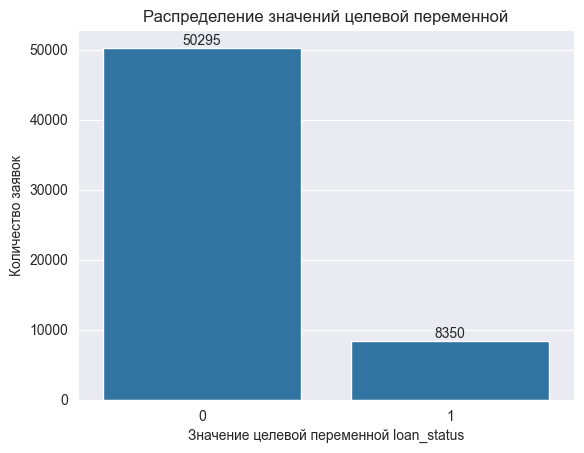

In [32]:
count_plot_target = sns.countplot(x=df['loan_status'])
count_plot_target.set_title("Распределение значений целевой переменной")
count_plot_target.set_xlabel("Значение целевой переменной loan_status")
count_plot_target.set_ylabel("Количество заявок")
for container in count_plot_target.containers:
    count_plot_target.bar_label(container)

Виден явный дисбаланс значений целевой переменной: всего лишь 8350 одобрений при 50295 отказах, то есть 1 к 6, процент одобрений составляет 14,24%.

In [33]:
df['loan_status'].value_counts(normalize=True) * 100

loan_status
0    85.761787
1    14.238213
Name: proportion, dtype: float64

Удалим столбец "id" из данных

In [34]:
df.drop(columns=['id'], inplace=True, axis=1)

In [35]:
loan_grade_order = sorted(df["loan_grade"].unique())

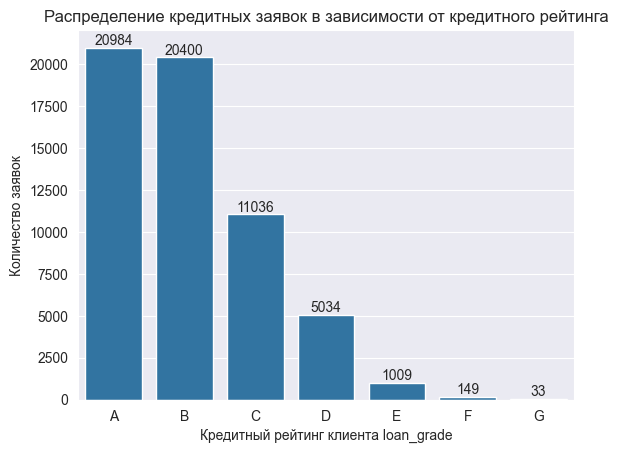

In [36]:
count_plot_loan_grade = sns.countplot(
    x="loan_grade",
    data=df,
    order=loan_grade_order
)
count_plot_loan_grade.set_title("Распределение кредитных заявок в зависимости от кредитного рейтинга")
count_plot_loan_grade.set_xlabel("Кредитный рейтинг клиента loan_grade")
count_plot_loan_grade.set_ylabel("Количество заявок")
for container in count_plot_loan_grade.containers:
    count_plot_loan_grade.bar_label(container)

Как видно из гистограммы, наибольшее количество заявок на кредитование организация получает от клиентов с кредитным высоким рейтингом (A и B).

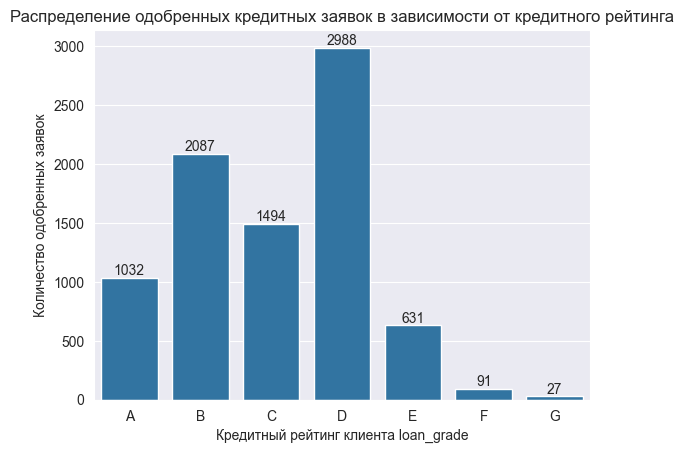

In [37]:
count_plot_loan_grade = sns.countplot(
    x="loan_grade",
    data=df[df["loan_status"] == 1],
    order=loan_grade_order
)
count_plot_loan_grade.set_title("Распределение одобренных кредитных заявок в зависимости от кредитного рейтинга")
count_plot_loan_grade.set_xlabel("Кредитный рейтинг клиента loan_grade")
count_plot_loan_grade.set_ylabel("Количество одобренных заявок")
for container in count_plot_loan_grade.containers:
    count_plot_loan_grade.bar_label(container)

Однако чаще всего кредиты выдаются клиентам со средним кредитным рейтингом (D).

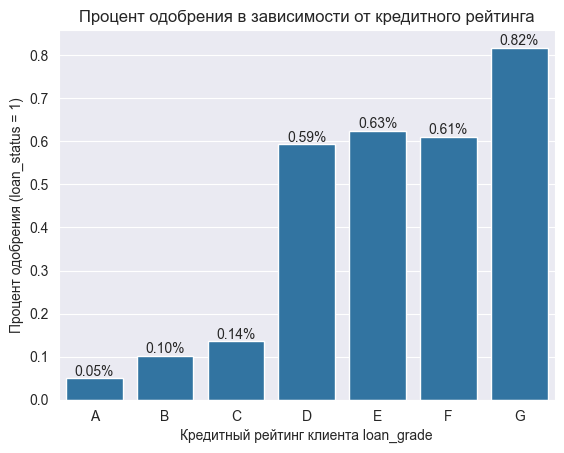

In [38]:
loan_grade_barplot = sns.barplot(
    data=df,
    x="loan_grade",
    y="loan_status",
    order=loan_grade_order,
    errorbar=None
)
loan_grade_barplot.set_title("Процент одобрения в зависимости от кредитного рейтинга")
loan_grade_barplot.set_xlabel("Кредитный рейтинг клиента loan_grade")
loan_grade_barplot.set_ylabel("Процент одобрения (loan_status = 1)")
for container in loan_grade_barplot.containers:
    loan_grade_barplot.bar_label(container, fmt="%.2f%%")

plt.show()

А самый высокий процент одобрения кредита у клиентов с самым низким рейтингом (G). Таким образом, делаем вывод, что организация является микрофинансовой, которая имеет высокий аппетит к риску при рассмотрении вопроса о выдаче кредита (т.е. у клиента с кредитным рейтингом средним и ниже больше шанс получить займ, чем у клиента с высоким рейтингом).

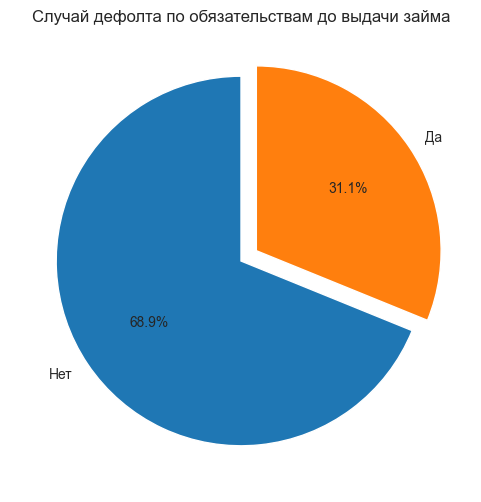

In [39]:
plt.figure(figsize=(6, 6))
plt.pie(
    df[df["loan_status"] == 1]["cb_person_default_on_file"].value_counts(),
    autopct="%1.1f%%",
    startangle=90,
    explode=[0, 0.1],
    labels=["Нет", "Да"]
)
plt.title("Случай дефолта по обязательствам до выдачи займа")
plt.show()

Как мы видим, даже признак дефолта не является автоматическим отказом для выдачи кредита.

## Матрица корреляций

interval columns not set, guessing: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'loan_status']


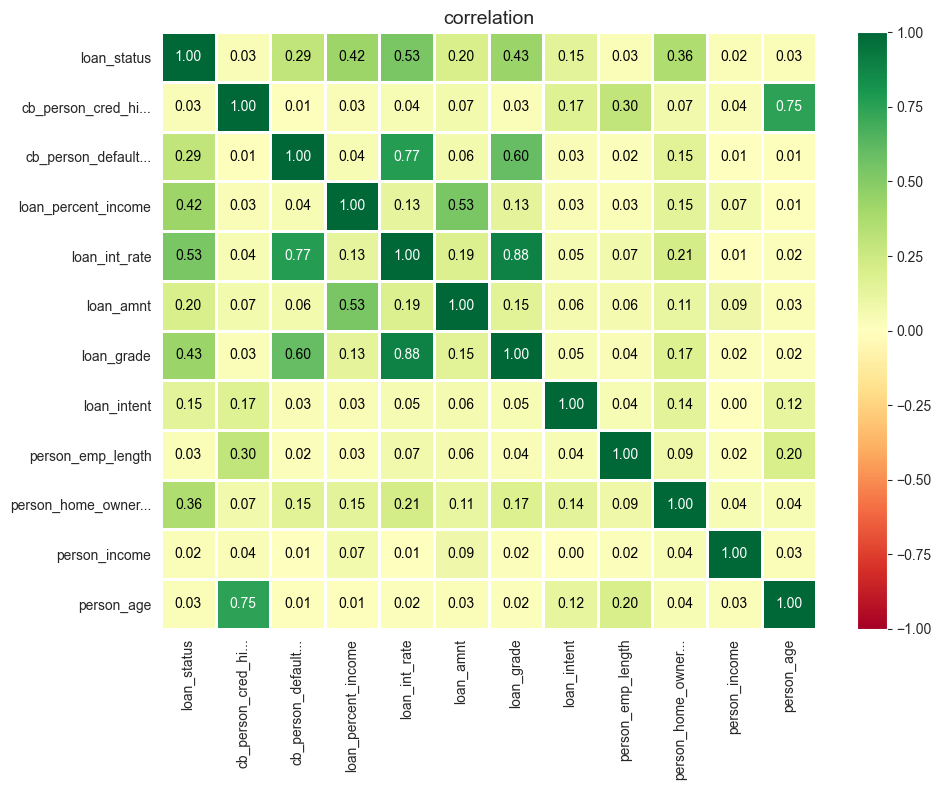

In [40]:
corr_matrix = df.phik_matrix()
plot_correlation_matrix(corr_matrix.values, x_labels=corr_matrix.columns, y_labels=corr_matrix.index, figsize=(10, 8))

Высокая корреляция наблюдается между следующими признаками: возраст клиента и длина его кредитной истории (0.75), процентная ставка и случай дефолта (0.77), процентная ставка и кредитный рейтинг (0.88). Нами было решено удалить возраст клиента и процентную ставку из датасета при создании модели.

Корреляционная матрица числовых признаков от цели:

person_income                -0.169956
person_emp_length            -0.100428
loan_intent                  -0.048751
cb_person_cred_hist_length   -0.003030
person_age                   -0.001130
loan_amnt                     0.144982
cb_person_default_on_file     0.186962
person_home_ownership         0.220167
loan_int_rate                 0.338948
loan_percent_income           0.378280
loan_grade                    0.385908
dtype: float64


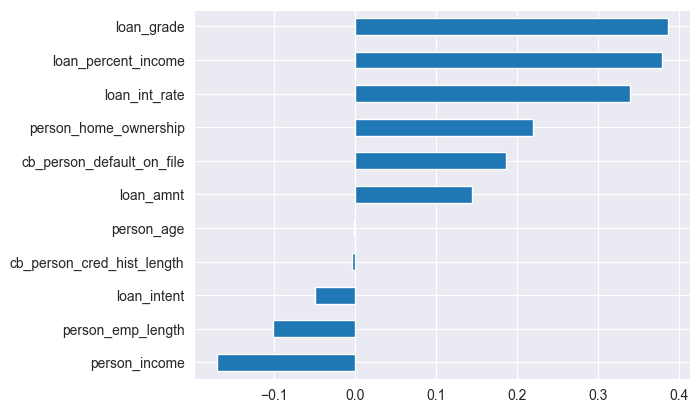

In [41]:
df['loan_grade'] = df['loan_grade'].map({'A':0, 'B':1, 'C':2, 'D':3, 'E':4, 'F':5, 'G':6})
df['cb_person_default_on_file'] = df['cb_person_default_on_file'].map({'N': 0, 'Y': 1})

categorical_cols = df.select_dtypes(include=['object']).columns

le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le
target_corrm = df.corrwith(df['loan_status']).drop(['loan_status']).sort_values()
target_corrm.plot(kind='barh')
print('Корреляционная матрица числовых признаков от цели:\n')
print(target_corrm)

# Класс для визуализации

In [42]:
class ModelVisualizer:
    def __init__(self, model, X: np.ndarray, y: np.ndarray, name):
        self.model = model
        self.X = X
        self.y = y
        self.name = name

    def _get_predictions(self):
        return self.model.predict_proba(self.X)[:, 1]

    def save_figure(self, fig: go.Figure, filename: str, file_format: str = 'png') -> None:
        if not os.path.exists(f'visualizations/{self.name}'):
            os.makedirs(f'visualizations/{self.name}')

        file_path = f'visualizations/{self.name}/{filename}.{file_format}'
        fig.write_image(file_path)
        print(f"График сохранен в {file_path}")

    def plot_roc_curve(self) -> None:
        y_pred_proba = self._get_predictions()
        fpr, tpr, thresholds = roc_curve(self.y, y_pred_proba)
        roc_auc = auc(fpr, tpr)

        fig = go.Figure()

        fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'ROC curve (AUC = {roc_auc:.2f})'))
        fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='Random', line={'dash': 'dash'}))

        fig.update_layout(
            title="ROC Curve",
            xaxis_title="False Positive Rate",
            yaxis_title="True Positive Rate",
            showlegend=True
        )

        self.save_figure(fig, 'roc_curve')

        fig.show()

    def plot_precision_recall_curve(self) -> go.Figure:
        y_pred_proba = self._get_predictions()
        precision, recall, _ = precision_recall_curve(self.y, y_pred_proba)

        fig = go.Figure()

        fig.add_trace(go.Scatter(x=recall, y=precision, mode='lines', name="Precision-Recall curve"))

        fig.update_layout(
            title="Precision-Recall Curve",
            xaxis_title="Recall",
            yaxis_title="Precision",
            showlegend=True
        )

        self.save_figure(fig, 'precision-recall_curve')

        return fig

    def plot_confusion_matrix(self) -> go.Figure:
        y_pred = self.model.predict(self.X)
        cm = confusion_matrix(self.y, y_pred)

        cm_df = pd.DataFrame(cm, index=['True Class 0', 'True Class 1'], columns=['Predicted 0', 'Predicted 1'])

        fig = px.imshow(cm_df, text_auto=True, color_continuous_scale='Blues', title='Confusion Matrix')

        fig.update_layout(
            xaxis_title="Predicted Labels",
            yaxis_title="True Labels",
            showlegend=False
        )

        self.save_figure(fig, 'confusion_matrix')

        return fig

    def plot_metrics_comparison(self) -> go.Figure:
        y_pred_proba = self._get_predictions()

        roc_auc = roc_auc_score(self.y, y_pred_proba)
        pr_auc = average_precision_score(self.y, y_pred_proba)
        precision = precision_score(self.y, (y_pred_proba > 0.5))
        recall = recall_score(self.y, (y_pred_proba > 0.5))
        f1 = f1_score(self.y, (y_pred_proba > 0.5))

        metrics = ['ROC AUC', 'PR AUC', 'Precision', 'Recall', 'F1']
        values = [roc_auc, pr_auc, precision, recall, f1]

        fig = go.Figure(
            go.Bar(
                x=metrics,
                y=values,
                marker=dict(color='royalblue'),
                text=[f"{v:.4f}" for v in values],
                textposition='auto',
                textfont=dict(size=12)
            )
        )

        fig.update_layout(
            title="Model Performance Metrics",
            xaxis_title="Metrics",
            yaxis_title="Value",
            yaxis=dict(range=[0, 1]),
            showlegend=False
        )

        self.save_figure(fig, 'metrics_comparison')

        return fig

    def plot_feature_importance(self) -> None:
        if hasattr(self.model, "named_steps"):
            estimator = self.model.named_steps.get("classifier", self.model)
        else:
            estimator = self.model

        if hasattr(estimator, "feature_importances_"):
            importances = estimator.feature_importances_
            title = "Feature Importance"
        elif hasattr(estimator, "coef_"):
            importances = np.abs(estimator.coef_).ravel()
            title = "Feature Importance (absolute coefficients)"
        else:
            print("Модель не поддерживает отображение важности признаков.")
            return

        importances = np.asarray(importances).ravel()

        feature_names = None
        if hasattr(self.model, "named_steps") and "preprocessor" in self.model.named_steps:
            X_trans = self.model.named_steps["preprocessor"].transform(self.X.iloc[:5] if hasattr(self.X, "iloc") else self.X[:5])
            if hasattr(X_trans, "columns"):
                feature_names = list(X_trans.columns)

        if feature_names is None:
            feature_names = [f"Feature {i}" for i in range(len(importances))]

        n = min(len(feature_names), len(importances))
        feature_names = feature_names[:n]
        importances = importances[:n]

        order = np.argsort(importances)
        feature_names = [feature_names[i] for i in order]
        importances = importances[order]

        fig = go.Figure()
        fig.add_trace(go.Bar(x=importances, y=feature_names, orientation="h"))
        fig.update_layout(title=title, xaxis_title="Importance", yaxis_title="Feature", showlegend=False)

        self.save_figure(fig, "feature_importance")
        fig.show()




# Класс для фильтрации выбросов

In [43]:
Rule = Callable[[pd.DataFrame], pd.Series]

@dataclass
class RowFilter:
    rules: List[Rule] = field(default_factory=list)

    def add_rule(self, rule: Rule) -> "RowFilter":
        self.rules.append(rule)
        return self

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        df2 = df.copy()
        if not self.rules:
            return df2

        mask = pd.Series(True, index=df2.index)
        for rule in self.rules:
            mask &= rule(df2)

        return df2.loc[mask].copy()

    def summary(self, df_before: pd.DataFrame, df_after: pd.DataFrame) -> Dict[str, Any]:
        return {
            "before_rows": len(df_before),
            "after_rows": len(df_after),
            "removed_rows": len(df_before) - len(df_after),
        }

In [44]:
FeatureFn = Callable[[pd.DataFrame], pd.DataFrame]

@dataclass
class FeatureBuilder:
    steps: List[FeatureFn] = field(default_factory=list)

    def add(self, fn: FeatureFn) -> "FeatureBuilder":
        self.steps.append(fn)
        return self

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        df2 = df.copy()
        for fn in self.steps:
            df2 = fn(df2)
        return df2

In [45]:
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd

class FeatureBuilderTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, builder: FeatureBuilder):
        self.builder = builder

    def fit(self, X: pd.DataFrame, y=None):
        return self

    def transform(self, X: pd.DataFrame):
        return self.builder.transform(X)

In [46]:
class DropColumns(BaseEstimator, TransformerMixin):
    def __init__(self, columns: Optional[List[str]] = None):
        self.columns = columns or []

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df = X.copy()
        cols = [c for c in self.columns if c in df.columns]
        return df.drop(columns=cols) if cols else df

In [47]:
class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold: float = 0.8, method: str = "pearson"):
        self.threshold = threshold
        self.method = method
        self.to_drop_: Optional[List[str]] = None

    def fit(self, X, y=None):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)

        corr = X.corr(method=self.method).abs()

        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        self.to_drop_ = [col for col in upper.columns if any(upper[col] > self.threshold)]
        return self

    def transform(self, X):
        if self.to_drop_ is None:
            raise ValueError("CorrelationFilter не обучен. Сначала fit().")
        if isinstance(X, pd.DataFrame):
            return X.drop(columns=[c for c in self.to_drop_ if c in X.columns])
        else:
            df = pd.DataFrame(X)
            df = df.drop(columns=[c for c in self.to_drop_ if c in df.columns])
            return df

In [48]:
class ManualMapper(BaseEstimator, TransformerMixin):
    def __init__(self, mappings: Optional[Dict[str, Dict[Any, Any]]] = None, unknown_value: int = -1):
        self.mappings = mappings or {}
        self.unknown_value = unknown_value

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df = X.copy()
        for col, mapping in self.mappings.items():
            if col in df.columns:
                df[col] = df[col].map(mapping).fillna(self.unknown_value).astype(int)
        return df

In [49]:
class OneHotDummifier(BaseEstimator, TransformerMixin):
    def __init__(self, columns: Optional[List[str]] = None, drop_first: bool = True):
        self.columns = columns or []
        self.drop_first = drop_first
        self.columns_: Optional[List[str]] = None

    def fit(self, X, y=None):
        df = X.copy()
        cols = [c for c in self.columns if c in df.columns]
        if cols:
            df = pd.get_dummies(df, columns=cols, drop_first=self.drop_first)
        self.columns_ = list(df.columns)
        return self

    def transform(self, X):
        if self.columns_ is None:
            raise ValueError("OneHotDummifier не обучен. Сначала fit().")
        df = X.copy()
        cols = [c for c in self.columns if c in df.columns]
        if cols:
            df = pd.get_dummies(df, columns=cols, drop_first=self.drop_first)
        return df.reindex(columns=self.columns_, fill_value=0)

# Базовый класс модели

In [50]:
class BaseModel(ABC):
    def __init__(self, random_state: int = 42):
        self.random_state = random_state
        self.model = None
        self.best_params_ = None
        self.best_score_ = None
        self.train_report_ = None

    @abstractmethod
    def create_pipeline(self) -> Pipeline:
        pass

    @abstractmethod
    def get_param_grid(self) -> List[Dict]:
        pass

    def train(self, X_train: np.ndarray, y_train: np.ndarray, cv: int = 3,
              scoring: str = 'roc_auc', n_jobs: int = -1) -> None:

        pipeline = self.create_pipeline()
        param_grid = self.get_param_grid()

        skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=self.random_state)

        rs = RandomizedSearchCV(
            estimator=pipeline,
            param_distributions=param_grid,
            n_iter=50,
            scoring="roc_auc",
            cv=skf,
            n_jobs=-1,
            random_state=self.random_state,
            verbose=1
        )

        tracemalloc.start()
        t0 = time.perf_counter()
        rs.fit(X_train, y_train)
        elapsed = time.perf_counter() - t0
        current, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        self.model = rs.best_estimator_
        self.best_params_ = rs.best_params_
        self.best_score_ = rs.best_score_

        n_features = None
        try:
            Xt = self.model[:-1].transform(X_train.iloc[:5] if hasattr(X_train, "iloc") else X_train[:5])
            n_features = Xt.shape[1]
        except Exception:
            pass

        self.train_report_ = {
            "algo": self.__class__.__name__,
            "cv": cv,
            "scoring": scoring,
            "n_rows": len(X_train),
            "n_features_after_preprocess": n_features,
            "elapsed_sec": float(elapsed),
            "py_mem_peak_mb": float(peak / (1024 ** 2)),
            "best_score": float(self.best_score_),
            "best_params": dict(self.best_params_),
        }

        print(f'Лучшие параметры: {self.best_params_}')
        print(f'Лучшее качество на кросс-валидации: {self.best_score_:.4f}')

    @abstractmethod
    def suggest_params(self, trial: optuna.trial.Trial) -> Dict[str, Any]:
        pass

    def train_optuna(
            self,
            X_train,
            y_train,
            cv: int = 3,
            scoring: str = "roc_auc",
            n_trials: int = 100,
            n_jobs: int = -1,
            timeout: int | None = None,
            study_name: str | None = None,
    ) -> None:
        pipeline = self.create_pipeline()
        skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=self.random_state)

        tracemalloc.start()
        t0 = time.perf_counter()

        def objective(trial: optuna.trial.Trial) -> float:
            params = self.suggest_params(trial)
            model = pipeline.set_params(**params)

            scores = cross_val_score(
                model,
                X_train,
                y_train,
                cv=skf,
                scoring=scoring,
                n_jobs=n_jobs,
            )
            return float(scores.mean())

        study = optuna.create_study(
            direction="maximize",
            sampler=TPESampler(seed=self.random_state),
            pruner=MedianPruner(n_startup_trials=10),
            study_name=study_name,
        )

        study.optimize(objective, n_trials=n_trials, timeout=timeout, show_progress_bar=True)

        elapsed = time.perf_counter() - t0
        current, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        # обучаем лучший пайплайн на всём train
        self.best_params_ = study.best_params
        self.best_score_ = study.best_value
        self.model = pipeline.set_params(**self.best_params_).fit(X_train, y_train)

        print(f"Лучшие параметры: {self.best_params_}")
        print(f"Лучшее качество на кросс-валидации: {self.best_score_:.4f}")

        self.train_report_ = {
            "algo": self.__class__.__name__,
            "cv": cv,
            "scoring": scoring,
            "n_rows": len(X_train),
            "elapsed_sec": float(elapsed),
            "py_mem_peak_mb": float(peak / (1024 ** 2)),
            "best_score": float(self.best_score_),
            "best_params": dict(self.best_params_),
            "n_trials": n_trials,
        }

    def predict(self, X: np.ndarray) -> np.ndarray:
        if self.model is None:
            raise ValueError("Модель не обучена. Сначала вызовите метод train()")
        return self.model.predict(X)

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        if self.model is None:
            raise ValueError("Модель не обучена. Сначала вызовите метод train()")
        return self.model.predict_proba(X)

# Логистическая регрессия

In [51]:
class LogisticRegressionModel(BaseModel):

    def __init__(
            self,
            random_state: int = 42,
            class_weight_options: Optional[List] = None,
            drop_cols: Optional[List[str]] = None,
            ohe_cols: Optional[List[str]] = None,
            feature_builder: FeatureBuilder | None = None,
            manual_mappings: Optional[Dict[str, Dict[Any, Any]]] = None,
            corr_threshold: float = 0.8,
            ohe_drop_first: bool = True,
            unknown_value: int = -1,
            max_iter: int = 1000,
    ):
        super().__init__(random_state)
        self.class_weight_options = class_weight_options or ["balanced", None]

        self.feature_builder = feature_builder or FeatureBuilder()
        self.drop_cols = drop_cols or ["id", "person_age", "loan_int_rate"]
        self.ohe_cols = ohe_cols or ["person_home_ownership", "loan_intent"]
        self.manual_mappings = manual_mappings or {
            "loan_grade": {"A": 0, "B": 1, "C": 2, "D": 3, "E": 4, "F": 5, "G": 6},
            "cb_person_default_on_file": {"N": 0, "Y": 1},
        }
        self.corr_threshold = corr_threshold
        self.ohe_drop_first = ohe_drop_first
        self.unknown_value = unknown_value

        self.max_iter = max_iter

    def create_pipeline(self) -> Pipeline:
        return Pipeline(steps = [
            ("features", FeatureBuilderTransformer(self.feature_builder)),
            ("drop", DropColumns(columns=self.drop_cols)),
            ("map", ManualMapper(mappings=self.manual_mappings, unknown_value=self.unknown_value)),
            ("ohe", OneHotDummifier(columns=self.ohe_cols, drop_first=self.ohe_drop_first)),
            ("corr_filter", CorrelationFilter(threshold=self.corr_threshold)),
            ('scaler', StandardScaler()),
            ('logisticregression', LogisticRegression(
                random_state=self.random_state,
                n_jobs=-1,
                max_iter=1000
            )),
        ])

    def suggest_params(self, trial):
        penalty = trial.suggest_categorical("logisticregression__penalty", ["l1", "l2", "elasticnet"])
        trial.suggest_float("corr_filter__threshold", 0.75, 0.99)

        if penalty == "l1":
            solver = "saga"
        elif penalty == "elasticnet":
            solver = "saga"
        else:
            solver = trial.suggest_categorical("logisticregression__solver", ["lbfgs", "newton-cg", "saga"])

        params = {
            "logisticregression__penalty": penalty,
            "logisticregression__solver": solver,
            "logisticregression__C": trial.suggest_float("logisticregression__C", 1e-4, 1e2, log=True),
            "logisticregression__class_weight": trial.suggest_categorical("logisticregression__class_weight", [None, "balanced"]),
        }

        if penalty == "elasticnet":
            params["logisticregression__l1_ratio"] = trial.suggest_float("logisticregression__l1_ratio", 0.0, 1.0)

        return params

    def get_param_grid(self) -> List[Dict]:
        return [
            {
                "logisticregression__penalty": ["l1"],
                "logisticregression__solver": ["saga"],
                "logisticregression__C": loguniform(1e-4, 1e2),
                "logisticregression__class_weight": ["balanced", None],
            },
            {
                "logisticregression__penalty": ["l2"],
                "logisticregression__solver": ["lbfgs", "saga", "newton-cg"],
                "logisticregression__C": loguniform(1e-4, 1e2),
                "logisticregression__class_weight": ["balanced", None],
            },
            {
                "logisticregression__penalty": ["elasticnet"],
                "logisticregression__solver": ["saga"],
                "logisticregression__C": loguniform(1e-4, 1e2),
                "logisticregression__l1_ratio": uniform(0.0, 1.0),
                "logisticregression__class_weight": ["balanced", None],
            }
        ]

    def plot_threshold_analysis(self, X_test: np.ndarray, y_test: np.ndarray):
        if self.model is None:
            raise ValueError("Модель не обучена. Сначала вызовите метод train()")

        y_proba_pred = self.model.predict_proba(X_test)[:, 1]

        thresholds = np.arange(0.1, 1, 0.05)
        recall_scores = []
        precision_scores = []
        f1_scores = []

        for threshold in thresholds:
            y_pred = (y_proba_pred > threshold).astype(int)
            recall_scores.append(recall_score(y_test, y_pred, zero_division=0))
            precision_scores.append(precision_score(y_test, y_pred, zero_division=0))
            f1_scores.append(f1_score(y_test, y_pred, zero_division=0))

        plt.figure(figsize=(12, 6))
        plt.plot(thresholds, recall_scores, label='Recall', marker='o')
        plt.plot(thresholds, precision_scores, label='Precision', marker='s')
        plt.plot(thresholds, f1_scores, label='F1-score', marker='^')

        plt.title('Зависимость метрик от порога вероятности')
        plt.xlabel('Порог вероятности')
        plt.ylabel('Метрика')
        plt.xticks(thresholds, rotation=45)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

In [52]:
df = pd.read_csv("../data/train.csv")

f = RowFilter() \
    .add_rule(lambda d: d["person_age"] <= 122) \
    .add_rule(lambda d: d["person_emp_length"] <= d['person_age'] - 16)

df = f.transform(df)

fb = FeatureBuilder() \
    .add(lambda d: d.assign(income_loan_diff=d["person_income"] - d["loan_amnt"])) \
    .add(lambda d: d.assign(emp_age_ratio=d["person_emp_length"] / (d["person_age"].replace(0, pd.NA))))

X = df.drop(columns=["loan_status"])
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

lr_model = LogisticRegressionModel(feature_builder=fb)
lr_model.train_optuna(X_train, y_train, cv=5)

print(lr_model.train_report_)

[I 2025-12-23 07:50:40,662] A new study created in memory with name: no-name-f5ea21e1-20b8-48d7-ae15-17d4a1a9569e


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-12-23 07:50:43,944] Trial 0 finished with value: 0.8945606415288335 and parameters: {'logisticregression__penalty': 'l2', 'corr_filter__threshold': 0.8936780362072888, 'logisticregression__solver': 'lbfgs', 'logisticregression__C': 15.741890047456641, 'logisticregression__class_weight': 'balanced'}. Best is trial 0 with value: 0.8945606415288335.
[I 2025-12-23 07:50:45,092] Trial 1 finished with value: 0.8939706390477788 and parameters: {'logisticregression__penalty': 'l2', 'corr_filter__threshold': 0.8009613865627863, 'logisticregression__solver': 'saga', 'logisticregression__C': 0.14077923139972404, 'logisticregression__class_weight': None}. Best is trial 0 with value: 0.8945606415288335.
[I 2025-12-23 07:50:46,309] Trial 2 finished with value: 0.8939494610795278 and parameters: {'logisticregression__penalty': 'l1', 'corr_filter__threshold': 0.837926842390486, 'logisticregression__C': 0.054502936945582545, 'logisticregression__class_weight': None}. Best is trial 0 with value:

/Users/evgeny.lesovskiy/PyCharmProjects/cred/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/Users/evgeny.lesovskiy/PyCharmProjects/cred/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/Users/evgeny.lesovskiy/PyCharmProjects/cred/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/Users/evgeny.lesovskiy/PyCharmProjects/cred/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/Users/evgeny.lesovskiy/PyCharmProjects/cred/.venv/lib/python3.13/site-packages/skle

[I 2025-12-23 07:50:50,956] Trial 8 finished with value: 0.8644357333608852 and parameters: {'logisticregression__penalty': 'l1', 'corr_filter__threshold': 0.9351048832046269, 'logisticregression__C': 0.00027814285643757564, 'logisticregression__class_weight': None}. Best is trial 0 with value: 0.8945606415288335.


...

/Users/evgeny.lesovskiy/PyCharmProjects/cred/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/evgeny.lesovskiy/PyCharmProjects/cred/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/evgeny.lesovskiy/PyCharmProjects/cred/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/evgeny.lesovskiy/PyCharmProjects/cred/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/evgeny.lesovskiy/PyCharmProjects/cred/.venv/lib/python3.13/site-packages/skle

[I 2025-12-23 07:51:30,722] Trial 98 finished with value: 0.8945801712491317 and parameters: {'logisticregression__penalty': 'l2', 'corr_filter__threshold': 0.7564518741251635, 'logisticregression__solver': 'newton-cg', 'logisticregression__C': 0.33688301197098514, 'logisticregression__class_weight': 'balanced'}. Best is trial 88 with value: 0.8946029567741158.


/Users/evgeny.lesovskiy/PyCharmProjects/cred/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/evgeny.lesovskiy/PyCharmProjects/cred/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/evgeny.lesovskiy/PyCharmProjects/cred/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/evgeny.lesovskiy/PyCharmProjects/cred/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/evgeny.lesovskiy/PyCharmProjects/cred/.venv/lib/python3.13/site-packages/skle

[I 2025-12-23 07:51:31,051] Trial 99 finished with value: 0.8945860467271448 and parameters: {'logisticregression__penalty': 'l2', 'corr_filter__threshold': 0.7829714455829474, 'logisticregression__solver': 'newton-cg', 'logisticregression__C': 0.12456215268881153, 'logisticregression__class_weight': 'balanced'}. Best is trial 88 with value: 0.8946029567741158.
Лучшие параметры: {'logisticregression__penalty': 'l2', 'corr_filter__threshold': 0.756214164918467, 'logisticregression__solver': 'newton-cg', 'logisticregression__C': 0.048545162136502173, 'logisticregression__class_weight': 'balanced'}
Лучшее качество на кросс-валидации: 0.8946
{'algo': 'LogisticRegressionModel', 'cv': 5, 'scoring': 'roc_auc', 'n_rows': 43246, 'elapsed_sec': 50.38881383324042, 'py_mem_peak_mb': 9.694636344909668, 'best_score': 0.8946029567741158, 'best_params': {'logisticregression__penalty': 'l2', 'corr_filter__threshold': 0.756214164918467, 'logisticregression__solver': 'newton-cg', 'logisticregression__C':

/Users/evgeny.lesovskiy/PyCharmProjects/cred/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


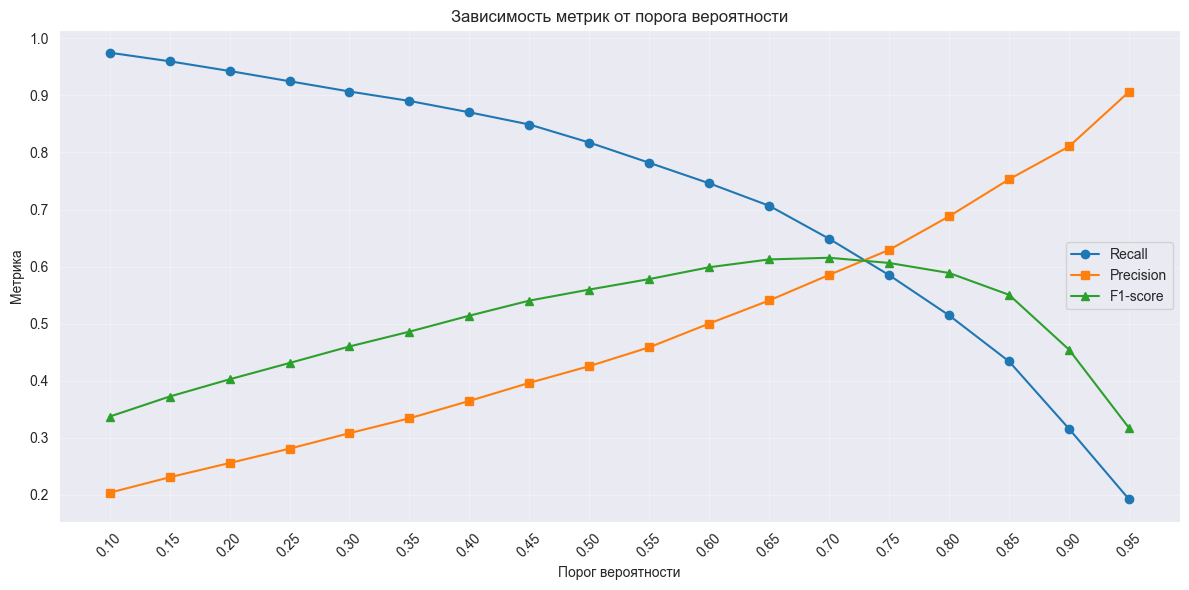

In [53]:
lr_model.plot_threshold_analysis(X_test, y_test)

In [54]:
lr_visualizer = ModelVisualizer(lr_model.model, X_test, y_test, "logistic_regression/optuna")

In [55]:
lr_visualizer.plot_roc_curve()

График сохранен в visualizations/logistic_regression/optuna/roc_curve.png


In [56]:
lr_visualizer.plot_metrics_comparison()

График сохранен в visualizations/logistic_regression/optuna/metrics_comparison.png


In [57]:
lr_visualizer.plot_confusion_matrix()

График сохранен в visualizations/logistic_regression/optuna/confusion_matrix.png


# Модель решающего дерева

In [58]:
class DecisionTreeModel(BaseModel):

    def __init__(
            self,
            random_state: int = 42,
            drop_cols: Optional[List[str]] = None,
            ohe_cols: Optional[List[str]] = None,
            manual_mappings: Optional[Dict[str, Dict[Any, Any]]] = None,
            unknown_value: int = -1,
            ohe_drop_first: bool = True,
            feature_builder: FeatureBuilder | None = None,
            use_corr_filter: bool = False,
            corr_threshold: float = 0.95,

            class_weight_options: Optional[List] = None,
            criterion_options: Optional[List[str]] = None,
            max_depth_options: Optional[List[Optional[int]]] = None,
            max_features_options: Optional[List[Any]] = None,
    ):
        super().__init__(random_state)

        self.drop_cols = drop_cols or ["id", "person_age", "loan_int_rate"]
        self.ohe_cols = ohe_cols or ["person_home_ownership", "loan_intent"]
        self.manual_mappings = manual_mappings or {
            "loan_grade": {"A": 0, "B": 1, "C": 2, "D": 3, "E": 4, "F": 5, "G": 6},
            "cb_person_default_on_file": {"N": 0, "Y": 1},
        }
        self.unknown_value = unknown_value
        self.ohe_drop_first = ohe_drop_first

        self.feature_builder = feature_builder or FeatureBuilder()

        self.use_corr_filter = use_corr_filter
        self.corr_threshold = corr_threshold

        self.class_weight_options = class_weight_options or [None, "balanced"]
        self.criterion_options = criterion_options or ["gini", "entropy", "log_loss"]
        self.max_depth_options = max_depth_options or [None, 3, 5, 7, 10, 15, 20, 30]
        self.max_features_options = max_features_options or [None, "sqrt", "log2", 0.3, 0.5]

    def create_pipeline(self) -> Pipeline:
        steps = [
            ("features", FeatureBuilderTransformer(self.feature_builder)),
            ("drop", DropColumns(columns=self.drop_cols)),
            ("map", ManualMapper(mappings=self.manual_mappings, unknown_value=self.unknown_value)),
            ("ohe", OneHotDummifier(columns=self.ohe_cols, drop_first=self.ohe_drop_first)),
        ]

        if self.use_corr_filter:
            steps.append(("corr_filter", CorrelationFilter(threshold=self.corr_threshold)))

        steps.append((
            "classifier",
            DecisionTreeClassifier(random_state=self.random_state)
        ))

        return Pipeline(steps=steps)

    def get_param_grid(self) -> List[Dict]:
        return [{
            'classifier__max_depth': range(1, 6),
            'classifier__min_samples_split': [2, 5, 10, 15, 20],
            'classifier__min_samples_leaf': [1, 3, 5, 10, 15],
            'classifier__max_features': [None, 'sqrt', 'log2', 0.3, 0.5],
            'classifier__criterion': ['gini', 'entropy'],
            'classifier__class_weight': [None, 'balanced']
        }]

    def suggest_params(self, trial):
        max_depth = trial.suggest_int("classifier__max_depth", 3, 12)

        min_samples_leaf = trial.suggest_int(
            "classifier__min_samples_leaf", 5, 50, log=True
        )

        min_samples_split = trial.suggest_int(
            "classifier__min_samples_split",
            max(2 * min_samples_leaf, 10),
            200,
            log=True,
        )

        return {
            "classifier__criterion": trial.suggest_categorical(
                "classifier__criterion", ["gini", "entropy"]
            ),

            "classifier__max_depth": max_depth,

            "classifier__min_samples_leaf": min_samples_leaf,
            "classifier__min_samples_split": min_samples_split,

            "classifier__max_features": trial.suggest_categorical(
                "classifier__max_features",
                ["sqrt", "log2", 0.3, 0.5]
            ),

            "classifier__class_weight": trial.suggest_categorical(
                "classifier__class_weight", [None, "balanced"]
            ),

            "classifier__ccp_alpha": trial.suggest_float(
                "classifier__ccp_alpha", 1e-6, 1e-3, log=True
            ),
        }

    def plot_tree_structure(self, columns) -> None:
        from sklearn import tree

        if self.model is None:
            raise ValueError("Модель не обучена. Сначала вызовите метод train()")

        tree_model = self.model.named_steps['classifier']

        plt.figure(figsize=(15, 10))
        tree.plot_tree(
            tree_model,
            feature_names=columns,
            class_names=["0 - не одобрено", "1 - одобрено"],
            filled=True,
        )
        plt.show()

In [59]:
df = pd.read_csv("../data/train.csv")

f = RowFilter() \
    .add_rule(lambda d: d["person_age"] <= 122) \
    .add_rule(lambda d: d["person_emp_length"] <= d['person_age'] - 16)

df = f.transform(df)

fb = FeatureBuilder() \
    .add(lambda d: d.assign(income_loan_diff=d["person_income"] - d["loan_amnt"])) \
    .add(lambda d: d.assign(emp_age_ratio=d["person_emp_length"] / (d["person_age"].replace(0, pd.NA))))

X = df.drop(columns=["loan_status"])
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

dt_model = DecisionTreeModel(feature_builder=fb)
dt_model.train_optuna(X_train, y_train, cv=5)

print(dt_model.train_report_)

[I 2025-12-23 07:51:43,825] A new study created in memory with name: no-name-863d6f95-a5a4-40f3-8f52-e43f37cb2eaf


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-12-23 07:51:44,374] Trial 0 finished with value: 0.8470485867393261 and parameters: {'classifier__max_depth': 6, 'classifier__min_samples_leaf': 45, 'classifier__min_samples_split': 162, 'classifier__criterion': 'gini', 'classifier__max_features': 0.3, 'classifier__class_weight': None, 'classifier__ccp_alpha': 0.0008123245085588687}. Best is trial 0 with value: 0.8470485867393261.
[I 2025-12-23 07:51:44,700] Trial 1 finished with value: 0.9109283182982632 and parameters: {'classifier__max_depth': 11, 'classifier__min_samples_leaf': 8, 'classifier__min_samples_split': 25, 'classifier__criterion': 'entropy', 'classifier__max_features': 0.5, 'classifier__class_weight': 'balanced', 'classifier__ccp_alpha': 1.2562773503807034e-05}. Best is trial 1 with value: 0.9109283182982632.
[I 2025-12-23 07:51:45,010] Trial 2 finished with value: 0.8856949018485167 and parameters: {'classifier__max_depth': 7, 'classifier__min_samples_leaf': 30, 'classifier__min_samples_split': 76, 'classifier__

In [60]:
dt_visualizer = ModelVisualizer(dt_model.model, X_test, y_test, "decision_tree/optuna")

In [61]:
dt_visualizer.plot_roc_curve()

График сохранен в visualizations/decision_tree/optuna/roc_curve.png


In [62]:
dt_visualizer.plot_confusion_matrix()

График сохранен в visualizations/decision_tree/optuna/confusion_matrix.png


In [63]:
dt_visualizer.plot_metrics_comparison()

График сохранен в visualizations/decision_tree/optuna/metrics_comparison.png


In [64]:
dt_visualizer.plot_feature_importance()

График сохранен в visualizations/decision_tree/optuna/feature_importance.png


# XGBoost

In [65]:
class XGBoostModel(BaseModel):

    def __init__(
            self,
            random_state: int = 42,

            drop_cols: Optional[List[str]] = None,
            ohe_cols: Optional[List[str]] = None,
            manual_mappings: Optional[Dict[str, Dict[Any, Any]]] = None,
            unknown_value: int = -1,
            ohe_drop_first: bool = True,
            feature_builder: FeatureBuilder | None = None,

            use_corr_filter: bool = False,
            corr_threshold: float = 0.95,

            tree_method: str = "hist",
            n_jobs: int = -1,
    ):
        super().__init__(random_state)

        self.drop_cols = drop_cols or ["id", "person_age", "loan_int_rate"]
        self.ohe_cols = ohe_cols or ["person_home_ownership", "loan_intent"]
        self.manual_mappings = manual_mappings or {
            "loan_grade": {"A": 0, "B": 1, "C": 2, "D": 3, "E": 4, "F": 5, "G": 6},
            "cb_person_default_on_file": {"N": 0, "Y": 1},
        }
        self.unknown_value = unknown_value
        self.ohe_drop_first = ohe_drop_first
        self.feature_builder = feature_builder or FeatureBuilder()

        self.use_corr_filter = use_corr_filter
        self.corr_threshold = corr_threshold

        self.tree_method = tree_method
        self.n_jobs = n_jobs

    def create_pipeline(self) -> Pipeline:
        steps = [
            ("features", FeatureBuilderTransformer(self.feature_builder)),
            ("drop", DropColumns(columns=self.drop_cols)),
            ("map", ManualMapper(mappings=self.manual_mappings, unknown_value=self.unknown_value)),
            ("ohe", OneHotDummifier(columns=self.ohe_cols, drop_first=self.ohe_drop_first)),
        ]

        if self.use_corr_filter:
            steps.append(("corr_filter", CorrelationFilter(threshold=self.corr_threshold)))

        steps.append((
            "classifier",
            XGBClassifier(
                random_state=self.random_state,
                n_jobs=self.n_jobs,
                tree_method=self.tree_method,
                objective="binary:logistic",
                eval_metric="logloss",
            )
        ))

        return Pipeline(steps=steps)

    def get_param_grid(self) -> List[Dict]:
        return [{
            'classifier__n_estimators': [100, 200, 300],
            'classifier__max_depth': [3, 5, 7, 9],
            'classifier__learning_rate': [0.01, 0.1, 0.3],
            'classifier__subsample': [0.8, 0.9, 1.0],
            'classifier__colsample_bytree': [0.8, 0.9, 1.0]
        }]

    def suggest_params(self, trial: optuna.trial.Trial) -> Dict[str, Any]:
        max_depth = trial.suggest_int("classifier__max_depth", 3, 8)

        params = {
            "classifier__n_estimators": trial.suggest_int("classifier__n_estimators", 300, 2000),
            "classifier__learning_rate": trial.suggest_float("classifier__learning_rate", 0.01, 0.2, log=True),

            "classifier__max_depth": max_depth,
            "classifier__min_child_weight": trial.suggest_int("classifier__min_child_weight", 1, 30, log=True),
            "classifier__gamma": trial.suggest_float("classifier__gamma", 0.0, 1.0),

            "classifier__subsample": trial.suggest_float("classifier__subsample", 0.6, 0.95),
            "classifier__colsample_bytree": trial.suggest_float("classifier__colsample_bytree", 0.5, 0.95),

            "classifier__reg_alpha": trial.suggest_float("classifier__reg_alpha", 1e-8, 1.0, log=True),
            "classifier__reg_lambda": trial.suggest_float("classifier__reg_lambda", 1e-3, 50.0, log=True),

            "classifier__scale_pos_weight": trial.suggest_float("classifier__scale_pos_weight", 0.5, 10.0),

            "classifier__max_delta_step": trial.suggest_int("classifier__max_delta_step", 0, 10),
        }

        return params


In [66]:
df = pd.read_csv("../data/train.csv")

f = RowFilter() \
    .add_rule(lambda d: d["person_age"] <= 122) \
    .add_rule(lambda d: d["person_emp_length"] <= d['person_age'] - 16)

df = f.transform(df)

fb = FeatureBuilder() \
    .add(lambda d: d.assign(income_loan_diff=d["person_income"] - d["loan_amnt"])) \
    .add(lambda d: d.assign(emp_age_ratio=d["person_emp_length"] / (d["person_age"].replace(0, pd.NA))))

X = df.drop(columns=["loan_status"])
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

xgb_model = XGBoostModel(feature_builder=fb)
xgb_model.train_optuna(X_train, y_train, cv=5)

print(xgb_model.train_report_)

[I 2025-12-23 07:52:19,004] A new study created in memory with name: no-name-3252de42-0d0e-41ce-beee-9c350b815dd1


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-12-23 07:52:21,341] Trial 0 finished with value: 0.943878332956575 and parameters: {'classifier__max_depth': 5, 'classifier__n_estimators': 1917, 'classifier__learning_rate': 0.08960785365368121, 'classifier__min_child_weight': 6, 'classifier__gamma': 0.15601864044243652, 'classifier__subsample': 0.6545980821176709, 'classifier__colsample_bytree': 0.5261376254756898, 'classifier__reg_alpha': 0.08499808989183001, 'classifier__reg_lambda': 0.667761551174708, 'classifier__scale_pos_weight': 7.226689489062432, 'classifier__max_delta_step': 0}. Best is trial 0 with value: 0.943878332956575.
[I 2025-12-23 07:52:24,595] Trial 1 finished with value: 0.9468478483582992 and parameters: {'classifier__max_depth': 8, 'classifier__n_estimators': 1715, 'classifier__learning_rate': 0.018891200276189398, 'classifier__min_child_weight': 1, 'classifier__gamma': 0.18340450985343382, 'classifier__subsample': 0.7064847850358382, 'classifier__colsample_bytree': 0.7361403942345071, 'classifier__reg_al

In [67]:
xgb_visualizer = ModelVisualizer(xgb_model.model, X_test, y_test, "xgboost/optuna")

In [68]:
xgb_visualizer.plot_confusion_matrix()

График сохранен в visualizations/xgboost/optuna/confusion_matrix.png


In [69]:
xgb_visualizer.plot_roc_curve()

График сохранен в visualizations/xgboost/optuna/roc_curve.png


In [70]:
xgb_visualizer.plot_metrics_comparison()

График сохранен в visualizations/xgboost/optuna/metrics_comparison.png


In [71]:
xgb_visualizer.plot_feature_importance()

График сохранен в visualizations/xgboost/optuna/feature_importance.png


03 - до добавления нового признака
04 - после добавления нового признака
05 - после удаления маловажных фич

# Random Forest

In [72]:
class RandomForestModel(BaseModel):

    def __init__(
            self,
            random_state: int = 42,

            drop_cols: Optional[List[str]] = None,
            ohe_cols: Optional[List[str]] = None,
            manual_mappings: Optional[Dict[str, Dict[Any, Any]]] = None,
            unknown_value: int = -1,
            ohe_drop_first: bool = True,
            feature_builder: FeatureBuilder | None = None,

            use_corr_filter: bool = False,
            corr_threshold: float = 0.95,

            class_weight_options: Optional[List] = None,
            n_jobs: int = -1,
    ):
        super().__init__(random_state)

        self.drop_cols = drop_cols or ["id", "person_age", "loan_int_rate"]
        self.ohe_cols = ohe_cols or ["person_home_ownership", "loan_intent"]
        self.manual_mappings = manual_mappings or {
            "loan_grade": {"A": 0, "B": 1, "C": 2, "D": 3, "E": 4, "F": 5, "G": 6},
            "cb_person_default_on_file": {"N": 0, "Y": 1},
        }
        self.unknown_value = unknown_value
        self.ohe_drop_first = ohe_drop_first
        self.feature_builder = feature_builder or FeatureBuilder()

        self.use_corr_filter = use_corr_filter
        self.corr_threshold = corr_threshold

        self.class_weight_options = class_weight_options or [None, "balanced"]
        self.n_jobs = n_jobs

    def create_pipeline(self) -> Pipeline:
        steps = [
            ("features", FeatureBuilderTransformer(self.feature_builder)),
            ("drop", DropColumns(columns=self.drop_cols)),
            ("map", ManualMapper(mappings=self.manual_mappings, unknown_value=self.unknown_value)),
            ("ohe", OneHotDummifier(columns=self.ohe_cols, drop_first=self.ohe_drop_first)),
        ]

        if self.use_corr_filter:
            steps.append(("corr_filter", CorrelationFilter(threshold=self.corr_threshold)))

        steps.append((
            "classifier",
            RandomForestClassifier(
                random_state=self.random_state,
                n_jobs=self.n_jobs,
            )
        ))

        return Pipeline(steps=steps)

    def get_param_grid(self) -> List[Dict]:
        return [{
            'classifier__n_estimators': [100, 200, 300],
            'classifier__max_depth': range(1, 6),
            'classifier__min_samples_split': [2, 5, 10],
            'classifier__min_samples_leaf': [1, 2, 4],
            'classifier__class_weight': ['balanced', None]
        }]

    def suggest_params(self, trial: optuna.trial.Trial) -> Dict[str, Any]:
        max_depth = trial.suggest_int("classifier__max_depth", 5, 15)

        min_samples_leaf = trial.suggest_int(
            "classifier__min_samples_leaf", 5, 50, log=True
        )

        min_samples_split = trial.suggest_int(
            "classifier__min_samples_split",
            max(2 * min_samples_leaf, 10),
            200,
            log=True,
        )

        bootstrap = trial.suggest_categorical("classifier__bootstrap", [True, False])

        params = {
            "classifier__n_estimators": trial.suggest_int("classifier__n_estimators", 300, 1200),

            "classifier__max_depth": max_depth,
            "classifier__min_samples_leaf": min_samples_leaf,
            "classifier__min_samples_split": min_samples_split,

            "classifier__max_features": trial.suggest_categorical(
                "classifier__max_features",
                ["sqrt", "log2", 0.3, 0.5, 0.7]
            ),

            "classifier__bootstrap": bootstrap,

            "classifier__max_samples": (
                trial.suggest_float("classifier__max_samples", 0.6, 0.95)
                if bootstrap else None
            ),

            "classifier__class_weight": trial.suggest_categorical(
                "classifier__class_weight", [None, "balanced"]
            ),
        }

        return params




In [73]:
df = pd.read_csv("../data/train.csv")

f = RowFilter() \
    .add_rule(lambda d: d["person_age"] <= 122) \
    .add_rule(lambda d: d["person_emp_length"] <= d['person_age'] - 16)

df = f.transform(df)

fb = FeatureBuilder() \
    .add(lambda d: d.assign(income_loan_diff=d["person_income"] - d["loan_amnt"])) \
    .add(lambda d: d.assign(emp_age_ratio=d["person_emp_length"] / (d["person_age"].replace(0, pd.NA))))

X = df.drop(columns=["loan_status"])
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

rf_model = RandomForestModel(feature_builder=fb)
rf_model.train_optuna(X_train, y_train, cv=5)

print(rf_model.train_report_)

[I 2025-12-23 07:54:27,311] A new study created in memory with name: no-name-5978c2dc-480b-4969-a72a-81084badc6cb


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-12-23 07:54:31,155] Trial 0 finished with value: 0.9286141194748108 and parameters: {'classifier__max_depth': 9, 'classifier__min_samples_leaf': 45, 'classifier__min_samples_split': 162, 'classifier__bootstrap': True, 'classifier__n_estimators': 440, 'classifier__max_features': 'log2', 'classifier__max_samples': 0.939468448256698, 'classifier__class_weight': None}. Best is trial 0 with value: 0.9286141194748108.
[I 2025-12-23 07:54:35,134] Trial 1 finished with value: 0.9278876550655163 and parameters: {'classifier__max_depth': 7, 'classifier__min_samples_leaf': 7, 'classifier__min_samples_split': 31, 'classifier__bootstrap': True, 'classifier__n_estimators': 562, 'classifier__max_features': 'sqrt', 'classifier__max_samples': 0.8748115864875547, 'classifier__class_weight': 'balanced'}. Best is trial 0 with value: 0.9286141194748108.
[I 2025-12-23 07:54:45,015] Trial 2 finished with value: 0.9355648653236217 and parameters: {'classifier__max_depth': 11, 'classifier__min_samples_

In [74]:
rf_visualizer = ModelVisualizer(rf_model.model, X_test, y_test, "random_forest/optuna")

In [75]:
rf_visualizer.plot_confusion_matrix()

График сохранен в visualizations/random_forest/optuna/confusion_matrix.png


In [76]:
rf_visualizer.plot_roc_curve()

График сохранен в visualizations/random_forest/optuna/roc_curve.png


In [77]:
rf_visualizer.plot_metrics_comparison()

График сохранен в visualizations/random_forest/optuna/metrics_comparison.png


In [78]:
rf_visualizer.plot_feature_importance()

График сохранен в visualizations/random_forest/optuna/feature_importance.png


In [79]:
print(rf_model.model.named_steps['preprocessor'].preprocessor.drop_columns)

KeyError: 'preprocessor'

In [62]:
Xt = rf_model.model.named_steps['preprocessor'].transform(X_train.iloc[:5])
print("RAW:", X_train.shape, "TRANSFORMED:", Xt.shape)
print("Есть loan_int_rate после preprocess?", "loan_int_rate" in Xt.columns)

RAW: (43246, 13) TRANSFORMED: (5, 10)
Есть loan_int_rate после preprocess? False


/var/folders/nk/kp0c0wz51573dh8v740tfx30p__r1h/T/ipykernel_83541/1842874302.py:59: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/nk/kp0c0wz51573dh8v740tfx30p__r1h/T/ipykernel_83541/1842874302.py:60: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/nk/kp0c0wz51573dh8v740tfx30p__r1h/T/ipykernel_83541/1842874302.py:61: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in th

# LightGBM

In [44]:
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

lgbm_silent_params = {
    "classifier__verbosity": -1,
    "classifier__verbose": -1,
}

warnings.filterwarnings("ignore", message=".*LightGBM.*")
warnings.filterwarnings("ignore", message=".*No further splits with positive gain.*")

In [45]:
class LightGBMModel(BaseModel):
    def __init__(
            self,
            random_state: int = 42,

            drop_cols: Optional[List[str]] = None,
            ohe_cols: Optional[List[str]] = None,
            manual_mappings: Optional[Dict[str, Dict[Any, Any]]] = None,
            unknown_value: int = -1,
            ohe_drop_first: bool = True,
            feature_builder: FeatureBuilder | None = None,

            use_corr_filter: bool = False,
            corr_threshold: float = 0.95,

            class_weight_options: Optional[List] = None,
            n_jobs: int = -1,
    ):
        super().__init__(random_state)

        self.drop_cols = drop_cols or ["id", "person_age", "loan_int_rate"]
        self.ohe_cols = ohe_cols or ["person_home_ownership", "loan_intent"]
        self.manual_mappings = manual_mappings or {
            "loan_grade": {"A": 0, "B": 1, "C": 2, "D": 3, "E": 4, "F": 5, "G": 6},
            "cb_person_default_on_file": {"N": 0, "Y": 1},
        }
        self.unknown_value = unknown_value
        self.ohe_drop_first = ohe_drop_first
        self.feature_builder = feature_builder or FeatureBuilder()
        self.use_corr_filter = use_corr_filter
        self.corr_threshold = corr_threshold

        self.class_weight_options = class_weight_options or [None, "balanced"]
        self.n_jobs = n_jobs

    def create_pipeline(self) -> Pipeline:
        steps = [
            ("features", FeatureBuilderTransformer(self.feature_builder)),
            ("drop", DropColumns(columns=self.drop_cols)),
            ("map", ManualMapper(mappings=self.manual_mappings, unknown_value=self.unknown_value)),
            ("ohe", OneHotDummifier(columns=self.ohe_cols, drop_first=self.ohe_drop_first)),
        ]

        if self.use_corr_filter:
            steps.append(("corr_filter", CorrelationFilter(threshold=self.corr_threshold)))

        steps.append((
            "classifier",
            LGBMClassifier(
                random_state=self.random_state,
                n_jobs=self.n_jobs,
                verbose=-1,
                verbosity=-1,
            )
        ))
        return Pipeline(steps=steps)

    def get_param_grid(self) -> List[Dict]:
        return [{
            'classifier__n_estimators': [100, 200, 300],
            'classifier__max_depth': range(1, 6),
            'classifier__min_samples_split': [2, 5, 10],
            'classifier__min_samples_leaf': [1, 2, 4],
            'classifier__class_weight': ['balanced', None],

            "classifier__learning_rate": [0.01, 0.03, 0.05, 0.1],

            "classifier__verbosity": [-1],
            "classifier__verbose": [-1],
        }]

    def suggest_params(self, trial: optuna.trial.Trial) -> Dict[str, Any]:
        max_depth = trial.suggest_categorical(
            "classifier__max_depth", [-1, 3, 4, 5, 6, 7, 8, 10, 12]
        )

        if max_depth == -1:
            num_leaves = trial.suggest_int("classifier__num_leaves", 16, 192)
        else:
            upper = min(2 ** max_depth, 192)
            num_leaves = trial.suggest_int("classifier__num_leaves", 8, max(8, upper))

        learning_rate = trial.suggest_float("classifier__learning_rate", 0.01, 0.15, log=True)

        return {
            "classifier__boosting_type": "gbdt",

            "classifier__learning_rate": learning_rate,
            "classifier__n_estimators": trial.suggest_int("classifier__n_estimators", 500, 5000),

            "classifier__max_depth": max_depth,
            "classifier__num_leaves": num_leaves,

            "classifier__min_child_samples": trial.suggest_int("classifier__min_child_samples", 20, 300, log=True),
            "classifier__min_child_weight": trial.suggest_float("classifier__min_child_weight", 1e-3, 10.0, log=True),

            "classifier__min_split_gain": trial.suggest_float("classifier__min_split_gain", 0.0, 0.2),

            "classifier__subsample": trial.suggest_float("classifier__subsample", 0.6, 0.95),
            "classifier__subsample_freq": trial.suggest_int("classifier__subsample_freq", 1, 10),
            "classifier__colsample_bytree": trial.suggest_float("classifier__colsample_bytree", 0.5, 0.95),

            "classifier__max_bin": trial.suggest_categorical("classifier__max_bin", [127, 255, 511]),

            "classifier__reg_alpha": trial.suggest_float("classifier__reg_alpha", 1e-8, 1.0, log=True),
            "classifier__reg_lambda": trial.suggest_float("classifier__reg_lambda", 1e-3, 50.0, log=True),

            "classifier__class_weight": trial.suggest_categorical("classifier__class_weight", [None, "balanced"]),
        }




In [46]:
df = pd.read_csv("../data/train.csv")

f = RowFilter() \
    .add_rule(lambda d: d["person_age"] <= 122) \
    .add_rule(lambda d: d["person_emp_length"] <= d['person_age'] - 16)

df = f.transform(df)

fb = FeatureBuilder() \
    .add(lambda d: d.assign(income_loan_diff=d["person_income"] - d["loan_amnt"])) \
    .add(lambda d: d.assign(emp_age_ratio=d["person_emp_length"] / (d["person_age"].replace(0, pd.NA))))

X = df.drop(columns=["loan_status"])
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

lgbm_model = LightGBMModel(feature_builder=fb)
lgbm_model.train_optuna(X_train, y_train, cv=5)

print(lgbm_model.train_report_)

[I 2025-12-22 12:41:52,352] A new study created in memory with name: no-name-08d2a3a1-0aa8-4a61-82a1-1bd6bba24a5d


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-12-22 12:41:57,650] Trial 0 finished with value: 0.9496105829001976 and parameters: {'classifier__max_depth': 3, 'classifier__num_leaves': 8, 'classifier__learning_rate': 0.06803900745073706, 'classifier__n_estimators': 592, 'classifier__min_child_samples': 277, 'classifier__min_child_weight': 2.1368329072358767, 'classifier__min_split_gain': 0.04246782213565523, 'classifier__subsample': 0.6636387385224852, 'classifier__subsample_freq': 2, 'classifier__colsample_bytree': 0.636909009331792, 'classifier__max_bin': 127, 'classifier__reg_alpha': 0.000784915956255507, 'classifier__reg_lambda': 0.004523529917658778, 'classifier__class_weight': 'balanced'}. Best is trial 0 with value: 0.9496105829001976.
[I 2025-12-22 12:42:10,770] Trial 1 finished with value: 0.9497769320707155 and parameters: {'classifier__max_depth': 3, 'classifier__num_leaves': 8, 'classifier__learning_rate': 0.13060986669773664, 'classifier__n_estimators': 4846, 'classifier__min_child_samples': 178, 'classifier__

In [47]:
lgbm_visualizer = ModelVisualizer(lgbm_model.model, X_test, y_test, "lgbm/optuna")

In [48]:
lgbm_visualizer.plot_confusion_matrix()

График сохранен в visualizations/lgbm/optuna/confusion_matrix.png


In [49]:
lgbm_visualizer.plot_roc_curve()

График сохранен в visualizations/lgbm/optuna/roc_curve.png


In [50]:
lgbm_visualizer.plot_metrics_comparison()

График сохранен в visualizations/lgbm/optuna/metrics_comparison.png


In [84]:
lgbm_visualizer.plot_feature_importance()

C:\Users\rusla\AppData\Local\Temp\ipykernel_16344\519887750.py:59: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



График сохранен в visualizations/lgbm/optuna/feature_importance.png


In [83]:
from typing import Any, Dict, List, Optional
import optuna

from sklearn.pipeline import Pipeline
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


class StackingEnsembleModel(BaseModel):
    def __init__(
            self,
            random_state: int = 42,

            drop_cols: Optional[List[str]] = None,
            ohe_cols: Optional[List[str]] = None,
            manual_mappings: Optional[Dict[str, Dict[Any, Any]]] = None,
            unknown_value: int = -1,
            ohe_drop_first: bool = True,
            feature_builder: FeatureBuilder | None = None,

            use_corr_filter: bool = False,
            corr_threshold: float = 0.95,

            # stacking
            stack_cv: int = 5,                 # OOF для базовых моделей
            passthrough: bool = False,         # добавлять ли исходные фичи в meta-model
            meta_class_weight: Optional[str] = None,  # None / "balanced"

            n_jobs: int = -1,
    ):
        super().__init__(random_state)

        self.drop_cols = drop_cols or ["id", "person_age", "loan_int_rate"]
        self.ohe_cols = ohe_cols or ["person_home_ownership", "loan_intent"]
        self.manual_mappings = manual_mappings or {
            "loan_grade": {"A": 0, "B": 1, "C": 2, "D": 3, "E": 4, "F": 5, "G": 6},
            "cb_person_default_on_file": {"N": 0, "Y": 1},
        }
        self.unknown_value = unknown_value
        self.ohe_drop_first = ohe_drop_first
        self.feature_builder = feature_builder or FeatureBuilder()

        self.use_corr_filter = use_corr_filter
        self.corr_threshold = corr_threshold

        self.stack_cv = stack_cv
        self.passthrough = passthrough
        self.meta_class_weight = meta_class_weight
        self.n_jobs = n_jobs

        self.lgbm_params: Dict[str, Any] = {}
        self.rf_params: Dict[str, Any] = {}
        self.xgb_params: Dict[str, Any] = {}

        self.meta_params: Dict[str, Any] = {}

    def _preprocess_steps(self) -> List:
        steps = [
            ("features", FeatureBuilderTransformer(self.feature_builder)),
            ("drop", DropColumns(columns=self.drop_cols)),
            ("map", ManualMapper(mappings=self.manual_mappings, unknown_value=self.unknown_value)),
            ("ohe", OneHotDummifier(columns=self.ohe_cols, drop_first=self.ohe_drop_first)),
        ]
        if self.use_corr_filter:
            steps.append(("corr_filter", CorrelationFilter(threshold=self.corr_threshold)))
        return steps

    def create_pipeline(self) -> Pipeline:
        lgbm = LGBMClassifier(
            random_state=self.random_state,
            n_jobs=self.n_jobs,
            verbose=-1,
            verbosity=-1,
            **self.lgbm_params,
        )

        rf = RandomForestClassifier(
            random_state=self.random_state,
            n_jobs=self.n_jobs,
            **self.rf_params,
        )

        xgb = XGBClassifier(
            random_state=self.random_state,
            n_jobs=self.n_jobs,
            tree_method="hist",
            objective="binary:logistic",
            eval_metric="logloss",
            **self.xgb_params,
        )

        meta = LogisticRegression(
            random_state=self.random_state,
            max_iter=5000,
            class_weight=self.meta_class_weight,
            **self.meta_params,
        )

        stack = StackingClassifier(
            estimators=[("lgbm", lgbm), ("rf", rf), ("xgb", xgb)],
            final_estimator=meta,
            cv=self.stack_cv,
            stack_method="predict_proba",
            passthrough=self.passthrough,
            n_jobs=self.n_jobs,
        )

        return Pipeline(steps=[
            *self._preprocess_steps(),
            ("classifier", stack),
        ])

    def get_param_grid(self) -> List[Dict]:
        pass

    def suggest_params(self, trial: optuna.trial.Trial) -> Dict[str, Any]:
        meta_C = trial.suggest_float("meta__C", 1e-3, 50.0, log=True)
        meta_penalty = trial.suggest_categorical("meta__penalty", ["l2"])
        meta_solver = trial.suggest_categorical("meta__solver", ["lbfgs"])

        lgbm_lr = trial.suggest_float("lgbm__learning_rate", 0.01, 0.15, log=True)
        lgbm_n_estimators = trial.suggest_int("lgbm__n_estimators", 500, 4000)

        rf_n_estimators = trial.suggest_int("rf__n_estimators", 300, 1200)
        rf_max_depth = trial.suggest_int("rf__max_depth", 5, 18)

        xgb_lr = trial.suggest_float("xgb__learning_rate", 0.01, 0.2, log=True)
        xgb_n_estimators = trial.suggest_int("xgb__n_estimators", 300, 2500)
        xgb_max_depth = trial.suggest_int("xgb__max_depth", 3, 8)

        return {
            "classifier__final_estimator__C": meta_C,
            "classifier__final_estimator__penalty": meta_penalty,
            "classifier__final_estimator__solver": meta_solver,

            "classifier__lgbm__learning_rate": lgbm_lr,
            "classifier__lgbm__n_estimators": lgbm_n_estimators,

            "classifier__rf__n_estimators": rf_n_estimators,
            "classifier__rf__max_depth": rf_max_depth,

            "classifier__xgb__learning_rate": xgb_lr,
            "classifier__xgb__n_estimators": xgb_n_estimators,
            "classifier__xgb__max_depth": xgb_max_depth,
        }


In [84]:
df = pd.read_csv("../data/train.csv")

f = RowFilter() \
    .add_rule(lambda d: d["person_age"] <= 122) \
    .add_rule(lambda d: d["person_emp_length"] <= d['person_age'] - 16)

df = f.transform(df)

fb = FeatureBuilder() \
    .add(lambda d: d.assign(income_loan_diff=d["person_income"] - d["loan_amnt"])) \
    .add(lambda d: d.assign(emp_age_ratio=d["person_emp_length"] / (d["person_age"].replace(0, pd.NA))))

X = df.drop(columns=["loan_status"])
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

stacking_model = StackingEnsembleModel(feature_builder=fb)
stacking_model.train_optuna(X_train, y_train, cv=3, n_trials=10)

print(stacking_model.train_report_)

[I 2025-12-22 15:40:27,207] A new study created in memory with name: no-name-446829bb-5da9-48c8-872e-9610c79366d6


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2025-12-22 15:42:53,864] Trial 0 finished with value: 0.9477280582117893 and parameters: {'meta__C': 0.05753773794117188, 'meta__penalty': 'l2', 'meta__solver': 'lbfgs', 'lgbm__learning_rate': 0.13125830316209655, 'lgbm__n_estimators': 3062, 'rf__n_estimators': 839, 'rf__max_depth': 7, 'xgb__learning_rate': 0.015957084694148364, 'xgb__n_estimators': 427, 'xgb__max_depth': 8}. Best is trial 0 with value: 0.9477280582117893.
[I 2025-12-22 15:45:37,539] Trial 1 finished with value: 0.9525851108136246 and parameters: {'meta__C': 0.6677615511747083, 'meta__penalty': 'l2', 'meta__solver': 'lbfgs', 'lgbm__learning_rate': 0.06803900745073706, 'lgbm__n_estimators': 572, 'rf__n_estimators': 1173, 'rf__max_depth': 16, 'xgb__learning_rate': 0.018891200276189388, 'xgb__n_estimators': 700, 'xgb__max_depth': 4}. Best is trial 1 with value: 0.9525851108136246.
[I 2025-12-22 15:47:17,705] Trial 2 finished with value: 0.9516179654328969 and parameters: {'meta__C': 0.026892128247368887, 'meta__penalty

ValueError: Invalid parameter 'meta' for estimator Pipeline(steps=[('features',
                 FeatureBuilderTransformer(builder=FeatureBuilder(steps=[<function <lambda> at 0x0000015CC3D11BC0>,
                                                                         <function <lambda> at 0x0000015CC1D8D760>]))),
                ('drop',
                 DropColumns(columns=['id', 'person_age', 'loan_int_rate'])),
                ('map',
                 ManualMapper(mappings={'cb_person_default_on_file': {'N': 0,
                                                                      'Y': 1},
                                        'loan_grade': {'A': 0, 'B': 1, 'C': 2,
                                                       'D': 3, 'E': 4, 'F...
                                                               max_cat_to_onehot=None,
                                                               max_delta_step=None,
                                                               max_depth=

# Сравнение моделей

In [85]:
def evaluate_fitted(model, X, y, name: str):
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)[:, 1]
    else:
        proba = None

    pred = model.predict(X)

    return {
        "model": name,
        "roc_auc": roc_auc_score(y, proba) if proba is not None else np.nan,
        "pr_auc": average_precision_score(y, proba) if proba is not None else np.nan,
        "f1": f1_score(y, pred),
        "precision": precision_score(y, pred),
        "recall": recall_score(y, pred),
    }

trained_models = [
    ("logreg", lr_model.model),
    ("decision_tree", dt_model.model),
    ("random_forest", rf_model.model),
    ("xgboost", xgb_model.model),
    ("lightgbm", lgbm_model.model),
]

results = [evaluate_fitted(m, X_test, y_test, name) for name, m in trained_models]
compare_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False).reset_index(drop=True)
display(compare_df)

best_name = compare_df.iloc[0]["model"]
best_model = dict(trained_models)[best_name]
print("Лучшая по ROC-AUC на X_test:", best_name)


,model,roc_auc,pr_auc,f1,precision,recall
0,lightgbm,0.957304,0.875645,0.810405,0.904249,0.734208
1,xgboost,0.955326,0.873622,0.777188,0.740431,0.817784
2,random_forest,0.943434,0.855806,0.773778,0.759476,0.788630
3,decision_tree,0.926116,0.811600,0.724793,0.671222,0.787658
4,logreg,0.893714,0.666868,0.559827,0.425715,0.817298


Лучшая по ROC-AUC на X_test: lightgbm


# Обнаружение выбросов

In [77]:
X_train_iso = preprocessor.preprocess_train(X_train)

iso = IsolationForest(contamination=0.1)
iso.fit(X_train_iso)
iso_anomaly_labels = iso.predict(X_train_iso) == -1

lof = LocalOutlierFactor(contamination=0.1)
lof_pred = lof.fit_predict(X_train_iso)
lof_anomaly_labels = lof_pred == -1



anomaly_labels = iso_anomaly_labels & lof_anomaly_labels
print(sum(anomaly_labels))


x_clean_train = X_train_iso[~anomaly_labels]
y_clean_train = y_train[~anomaly_labels]

1478
